##Comparative Analysis of USA vs China Large Language Models

#### Group 3

## EDA - Exploratory Data Analysis

In [96]:
# •	Question Answering: SQuAD

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [1]:
from datasets import load_dataset

squad = load_dataset("squad")



C:\Users\Nisha\anaconda3\envs\mp_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
squad

DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 87599
    })
    validation: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 10570
    })
})

In [31]:
train_df

,id,title,context,question,answers
0,5733be284776f41900661182,University_of_Notre_Dame,"Architecturally, the school has a Catholic cha...",To whom did the Virgin Mary allegedly appear i...,"{'text': ['Saint Bernadette Soubirous'], 'answ..."
1,5733be284776f4190066117f,University_of_Notre_Dame,"Architecturally, the school has a Catholic cha...",What is in front of the Notre Dame Main Building?,"{'text': ['a copper statue of Christ'], 'answe..."
2,5733be284776f41900661180,University_of_Notre_Dame,"Architecturally, the school has a Catholic cha...",The Basilica of the Sacred heart at Notre Dame...,"{'text': ['the Main Building'], 'answer_start'..."
3,5733be284776f41900661181,University_of_Notre_Dame,"Architecturally, the school has a Catholic cha...",What is the Grotto at Notre Dame?,{'text': ['a Marian place of prayer and reflec...
4,5733be284776f4190066117e,University_of_Notre_Dame,"Architecturally, the school has a Catholic cha...",What sits on top of the Main Building at Notre...,{'text': ['a golden statue of the Virgin Mary'...
...,...,...,...,...,...
87594,5735d259012e2f140011a09d,Kathmandu,"Kathmandu Metropolitan City (KMC), in order to...",In what US state did Kathmandu first establish...,"{'text': ['Oregon'], 'answer_start': [229]}"
87595,5735d259012e2f140011a09e,Kathmandu,"Kathmandu Metropolitan City (KMC), in order to...",What was Yangon previously known as?,"{'text': ['Rangoon'], 'answer_start': [414]}"
87596,5735d259012e2f140011a09f,Kathmandu,"Kathmandu Metropolitan City (KMC), in order to...",With what Belorussian city does Kathmandu have...,"{'text': ['Minsk'], 'answer_start': [476]}"
87597,5735d259012e2f140011a0a0,Kathmandu,"Kathmandu Metropolitan City (KMC), in order to...",In what year did Kathmandu create its initial ...,"{'text': ['1975'], 'answer_start': [199]}"


In [4]:
train_df.head()


,id,title,context,question,answers
0,5733be284776f41900661182,University_of_Notre_Dame,"Architecturally, the school has a Catholic cha...",To whom did the Virgin Mary allegedly appear i...,"{'text': ['Saint Bernadette Soubirous'], 'answ..."
1,5733be284776f4190066117f,University_of_Notre_Dame,"Architecturally, the school has a Catholic cha...",What is in front of the Notre Dame Main Building?,"{'text': ['a copper statue of Christ'], 'answe..."
2,5733be284776f41900661180,University_of_Notre_Dame,"Architecturally, the school has a Catholic cha...",The Basilica of the Sacred heart at Notre Dame...,"{'text': ['the Main Building'], 'answer_start'..."
3,5733be284776f41900661181,University_of_Notre_Dame,"Architecturally, the school has a Catholic cha...",What is the Grotto at Notre Dame?,{'text': ['a Marian place of prayer and reflec...
4,5733be284776f4190066117e,University_of_Notre_Dame,"Architecturally, the school has a Catholic cha...",What sits on top of the Main Building at Notre...,{'text': ['a golden statue of the Virgin Mary'...
...,...,...,...,...,...
87594,5735d259012e2f140011a09d,Kathmandu,"Kathmandu Metropolitan City (KMC), in order to...",In what US state did Kathmandu first establish...,"{'text': ['Oregon'], 'answer_start': [229]}"
87595,5735d259012e2f140011a09e,Kathmandu,"Kathmandu Metropolitan City (KMC), in order to...",What was Yangon previously known as?,"{'text': ['Rangoon'], 'answer_start': [414]}"
87596,5735d259012e2f140011a09f,Kathmandu,"Kathmandu Metropolitan City (KMC), in order to...",With what Belorussian city does Kathmandu have...,"{'text': ['Minsk'], 'answer_start': [476]}"
87597,5735d259012e2f140011a0a0,Kathmandu,"Kathmandu Metropolitan City (KMC), in order to...",In what year did Kathmandu create its initial ...,"{'text': ['1975'], 'answer_start': [199]}"


In [5]:
val_df

,id,title,context,question,answers
0,56be4db0acb8001400a502ec,Super_Bowl_50,Super Bowl 50 was an American football game to...,Which NFL team represented the AFC at Super Bo...,"{'text': ['Denver Broncos', 'Denver Broncos', ..."
1,56be4db0acb8001400a502ed,Super_Bowl_50,Super Bowl 50 was an American football game to...,Which NFL team represented the NFC at Super Bo...,"{'text': ['Carolina Panthers', 'Carolina Panth..."
2,56be4db0acb8001400a502ee,Super_Bowl_50,Super Bowl 50 was an American football game to...,Where did Super Bowl 50 take place?,"{'text': ['Santa Clara, California', 'Levi's S..."
3,56be4db0acb8001400a502ef,Super_Bowl_50,Super Bowl 50 was an American football game to...,Which NFL team won Super Bowl 50?,"{'text': ['Denver Broncos', 'Denver Broncos', ..."
4,56be4db0acb8001400a502f0,Super_Bowl_50,Super Bowl 50 was an American football game to...,What color was used to emphasize the 50th anni...,"{'text': ['gold', 'gold', 'gold'], 'answer_sta..."
...,...,...,...,...,...
10565,5737aafd1c456719005744fb,Force,"The pound-force has a metric counterpart, less...",What is the metric term less used than the New...,"{'text': ['kilogram-force', 'pound-force', 'ki..."
10566,5737aafd1c456719005744fc,Force,"The pound-force has a metric counterpart, less...",What is the kilogram-force sometimes reffered ...,"{'text': ['kilopond', 'kilopond', 'kilopond', ..."
10567,5737aafd1c456719005744fd,Force,"The pound-force has a metric counterpart, less...",What is a very seldom used unit of mass in the...,"{'text': ['slug', 'metric slug', 'metric slug'..."
10568,5737aafd1c456719005744fe,Force,"The pound-force has a metric counterpart, less...",What seldom used term of a unit of force equal...,"{'text': ['kip', 'kip', 'kip', 'kip', 'kip'], ..."


In [6]:
train_df.head(10)

,id,title,context,question,answers
0,5733be284776f41900661182,University_of_Notre_Dame,"Architecturally, the school has a Catholic cha...",To whom did the Virgin Mary allegedly appear i...,"{'text': ['Saint Bernadette Soubirous'], 'answ..."
1,5733be284776f4190066117f,University_of_Notre_Dame,"Architecturally, the school has a Catholic cha...",What is in front of the Notre Dame Main Building?,"{'text': ['a copper statue of Christ'], 'answe..."
2,5733be284776f41900661180,University_of_Notre_Dame,"Architecturally, the school has a Catholic cha...",The Basilica of the Sacred heart at Notre Dame...,"{'text': ['the Main Building'], 'answer_start'..."
3,5733be284776f41900661181,University_of_Notre_Dame,"Architecturally, the school has a Catholic cha...",What is the Grotto at Notre Dame?,{'text': ['a Marian place of prayer and reflec...
4,5733be284776f4190066117e,University_of_Notre_Dame,"Architecturally, the school has a Catholic cha...",What sits on top of the Main Building at Notre...,{'text': ['a golden statue of the Virgin Mary'...
5,5733bf84d058e614000b61be,University_of_Notre_Dame,"As at most other universities, Notre Dame's st...",When did the Scholastic Magazine of Notre dame...,"{'text': ['September 1876'], 'answer_start': [..."
6,5733bf84d058e614000b61bf,University_of_Notre_Dame,"As at most other universities, Notre Dame's st...",How often is Notre Dame's the Juggler published?,"{'text': ['twice'], 'answer_start': [441]}"
7,5733bf84d058e614000b61c0,University_of_Notre_Dame,"As at most other universities, Notre Dame's st...",What is the daily student paper at Notre Dame ...,"{'text': ['The Observer'], 'answer_start': [598]}"
8,5733bf84d058e614000b61bd,University_of_Notre_Dame,"As at most other universities, Notre Dame's st...",How many student news papers are found at Notr...,"{'text': ['three'], 'answer_start': [126]}"
9,5733bf84d058e614000b61c1,University_of_Notre_Dame,"As at most other universities, Notre Dame's st...",In what year did the student paper Common Sens...,"{'text': ['1987'], 'answer_start': [908]}"


In [7]:
train_df.tail(10)

,id,title,context,question,answers
87589,5735d1a86c16ec1900b92831,Kathmandu,The main international airport serving Kathman...,What is Nepal's primary airport for internatio...,"{'text': ['Tribhuvan International Airport'], ..."
87590,5735d1a86c16ec1900b92832,Kathmandu,The main international airport serving Kathman...,"Starting in the center of Kathmandu, how many ...","{'text': ['6'], 'answer_start': [134]}"
87591,5735d1a86c16ec1900b92833,Kathmandu,The main international airport serving Kathman...,How many airlines use Tribhuvan International ...,"{'text': ['22'], 'answer_start': [297]}"
87592,5735d1a86c16ec1900b92834,Kathmandu,The main international airport serving Kathman...,From what city does Arkefly offer nonstop flig...,"{'text': ['Amsterdam'], 'answer_start': [698]}"
87593,5735d1a86c16ec1900b92835,Kathmandu,The main international airport serving Kathman...,Who operates flights between Kathmandu and Ist...,"{'text': ['Turkish Airlines'], 'answer_start':..."
87594,5735d259012e2f140011a09d,Kathmandu,"Kathmandu Metropolitan City (KMC), in order to...",In what US state did Kathmandu first establish...,"{'text': ['Oregon'], 'answer_start': [229]}"
87595,5735d259012e2f140011a09e,Kathmandu,"Kathmandu Metropolitan City (KMC), in order to...",What was Yangon previously known as?,"{'text': ['Rangoon'], 'answer_start': [414]}"
87596,5735d259012e2f140011a09f,Kathmandu,"Kathmandu Metropolitan City (KMC), in order to...",With what Belorussian city does Kathmandu have...,"{'text': ['Minsk'], 'answer_start': [476]}"
87597,5735d259012e2f140011a0a0,Kathmandu,"Kathmandu Metropolitan City (KMC), in order to...",In what year did Kathmandu create its initial ...,"{'text': ['1975'], 'answer_start': [199]}"
87598,5735d259012e2f140011a0a1,Kathmandu,"Kathmandu Metropolitan City (KMC), in order to...",What is KMC an initialism of?,"{'text': ['Kathmandu Metropolitan City'], 'ans..."


In [8]:
val_df.head(10)

,id,title,context,question,answers
0,56be4db0acb8001400a502ec,Super_Bowl_50,Super Bowl 50 was an American football game to...,Which NFL team represented the AFC at Super Bo...,"{'text': ['Denver Broncos', 'Denver Broncos', ..."
1,56be4db0acb8001400a502ed,Super_Bowl_50,Super Bowl 50 was an American football game to...,Which NFL team represented the NFC at Super Bo...,"{'text': ['Carolina Panthers', 'Carolina Panth..."
2,56be4db0acb8001400a502ee,Super_Bowl_50,Super Bowl 50 was an American football game to...,Where did Super Bowl 50 take place?,"{'text': ['Santa Clara, California', 'Levi's S..."
3,56be4db0acb8001400a502ef,Super_Bowl_50,Super Bowl 50 was an American football game to...,Which NFL team won Super Bowl 50?,"{'text': ['Denver Broncos', 'Denver Broncos', ..."
4,56be4db0acb8001400a502f0,Super_Bowl_50,Super Bowl 50 was an American football game to...,What color was used to emphasize the 50th anni...,"{'text': ['gold', 'gold', 'gold'], 'answer_sta..."
5,56be8e613aeaaa14008c90d1,Super_Bowl_50,Super Bowl 50 was an American football game to...,What was the theme of Super Bowl 50?,"{'text': ['""golden anniversary""', 'gold-themed..."
6,56be8e613aeaaa14008c90d2,Super_Bowl_50,Super Bowl 50 was an American football game to...,What day was the game played on?,"{'text': ['February 7, 2016', 'February 7', 'F..."
7,56be8e613aeaaa14008c90d3,Super_Bowl_50,Super Bowl 50 was an American football game to...,What is the AFC short for?,"{'text': ['American Football Conference', 'Ame..."
8,56bea9923aeaaa14008c91b9,Super_Bowl_50,Super Bowl 50 was an American football game to...,What was the theme of Super Bowl 50?,"{'text': ['""golden anniversary""', 'gold-themed..."
9,56bea9923aeaaa14008c91ba,Super_Bowl_50,Super Bowl 50 was an American football game to...,What does AFC stand for?,"{'text': ['American Football Conference', 'Ame..."


In [9]:
val_df.tail(10)

,id,title,context,question,answers
10560,5737a9afc3c5551400e51f61,Force,The connection between macroscopic nonconserva...,In what treatment are nonconservative and cons...,"{'text': ['statistical mechanics', 'statistica..."
10561,5737a9afc3c5551400e51f62,Force,The connection between macroscopic nonconserva...,What changes macroscopic closed system energies?,"{'text': ['nonconservative forces', 'internal ..."
10562,5737a9afc3c5551400e51f63,Force,The connection between macroscopic nonconserva...,What is the exchange of heat associated with?,"{'text': ['nonconservative forces', 'nonconser..."
10563,5737a9afc3c5551400e51f64,Force,The connection between macroscopic nonconserva...,What is the law of thermodynamics associated w...,"{'text': ['Second', 'Second law of thermodynam..."
10564,5737a9afc3c5551400e51f65,Force,The connection between macroscopic nonconserva...,What makes energy changes in a closed system?,"{'text': ['nonconservative forces', 'nonconser..."
10565,5737aafd1c456719005744fb,Force,"The pound-force has a metric counterpart, less...",What is the metric term less used than the New...,"{'text': ['kilogram-force', 'pound-force', 'ki..."
10566,5737aafd1c456719005744fc,Force,"The pound-force has a metric counterpart, less...",What is the kilogram-force sometimes reffered ...,"{'text': ['kilopond', 'kilopond', 'kilopond', ..."
10567,5737aafd1c456719005744fd,Force,"The pound-force has a metric counterpart, less...",What is a very seldom used unit of mass in the...,"{'text': ['slug', 'metric slug', 'metric slug'..."
10568,5737aafd1c456719005744fe,Force,"The pound-force has a metric counterpart, less...",What seldom used term of a unit of force equal...,"{'text': ['kip', 'kip', 'kip', 'kip', 'kip'], ..."
10569,5737aafd1c456719005744ff,Force,"The pound-force has a metric counterpart, less...",What is the seldom used force unit equal to on...,"{'text': ['sthène', 'sthène', 'sthène', 'sthèn..."


In [10]:
print(f"\nShape of the DataFrame: {train_df.shape} (Rows, Columns)")


Shape of the DataFrame: (87599, 5) (Rows, Columns)


In [11]:
print(f"\nShape of the DataFrame: {val_df.shape} (Rows, Columns)")


Shape of the DataFrame: (10570, 5) (Rows, Columns)


In [12]:
print("\nData types of each column:")
train_df.dtypes


Data types of each column:


id          object
title       object
context     object
question    object
answers     object
dtype: object

In [13]:
print("\nData types of each column:")
val_df.dtypes


Data types of each column:


id          object
title       object
context     object
question    object
answers     object
dtype: object

In [14]:
train_df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87599 entries, 0 to 87598
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        87599 non-null  object
 1   title     87599 non-null  object
 2   context   87599 non-null  object
 3   question  87599 non-null  object
 4   answers   87599 non-null  object
dtypes: object(5)
memory usage: 3.3+ MB


In [15]:
val_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10570 entries, 0 to 10569
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        10570 non-null  object
 1   title     10570 non-null  object
 2   context   10570 non-null  object
 3   question  10570 non-null  object
 4   answers   10570 non-null  object
dtypes: object(5)
memory usage: 413.0+ KB


In [16]:
train_df.columns

Index(['id', 'title', 'context', 'question', 'answers'], dtype='object')

In [17]:
val_df.columns

Index(['id', 'title', 'context', 'question', 'answers'], dtype='object')

In [33]:
print("\n===== MISSING VALUES =====")
print("Train Missing Values:\n", train_df.isnull().sum())
print("\nValidation Missing Values:\n", val_df.isnull().sum())


===== MISSING VALUES =====
Train Missing Values:
 id          0
title       0
context     0
question    0
answers     0
dtype: int64

Validation Missing Values:
 id          0
title       0
context     0
question    0
answers     0
dtype: int64


In [35]:
# missing answer text inside nested column
train_df["answer_missing"] = train_df["answers"].apply(lambda x: len(x["text"]) == 0)
val_df["answer_missing"] = val_df["answers"].apply(lambda x: len(x["text"]) == 0)

In [37]:
print("\nMissing Answers in Train:", train_df["answer_missing"].sum())
print("Missing Answers in Validation:", val_df["answer_missing"].sum())


Missing Answers in Train: 0
Missing Answers in Validation: 0


In [47]:
# Convert answers (dict) → text only so pandas can compare
train_df["answer_text"] = train_df["answers"].apply(lambda x: x["text"][0])

print("\n===== DUPLICATE CHECK =====")

# Duplicate questions
dup_q = train_df[train_df.duplicated(subset="question", keep=False)]
print("Duplicate Questions:", len(dup_q))

# Duplicate contexts
dup_c = train_df[train_df.duplicated(subset="context", keep=False)]
print("Duplicate Contexts:", len(dup_c))

# Duplicate Q+A pairs (now works!!)
dup_qa = train_df[train_df.duplicated(subset=["question", "answer_text"], keep=False)]
print("Duplicate QA pairs:", len(dup_qa))


===== DUPLICATE CHECK =====
Duplicate Questions: 460
Duplicate Contexts: 87284
Duplicate QA pairs: 208


In [ ]:
##  FEATURE ENGINEERING → LENGTH COLUMNS

In [49]:
train_df["question_length"] = train_df["question"].apply(len)
train_df["context_length"] = train_df["context"].apply(len)
train_df["answer_length"] = train_df["answers"].apply(lambda x: len(x["text"][0]))

In [51]:
##DESCRIPTIVE STATISTICS

In [53]:
print("\n===== DESCRIPTIVE STATISTICS =====")

print("\nQuestion Length Stats:\n", train_df["question_length"].describe())
print("\nContext Length Stats:\n", train_df["context_length"].describe())
print("\nAnswer Length Stats:\n", train_df["answer_length"].describe())

print("\n===== EXTRA METRICS =====")
print("Avg words per question:", train_df["question"].apply(lambda x: len(x.split())).mean())
print("Avg words per context:", train_df["context"].apply(lambda x: len(x.split())).mean())
print("Avg words per answer:", train_df["answers"].apply(lambda x: len(x["text"][0].split())).mean())


===== DESCRIPTIVE STATISTICS =====

Question Length Stats:
 count    87599.000000
mean        59.571137
std         89.027556
min          1.000000
25%         44.000000
50%         56.000000
75%         71.000000
max      25651.000000
Name: question_length, dtype: float64

Context Length Stats:
 count    87599.000000
mean       754.364216
std        307.396264
min        151.000000
25%        559.000000
50%        693.000000
75%        895.000000
max       3706.000000
Name: context_length, dtype: float64

Answer Length Stats:
 count    87599.000000
mean        20.147273
std         21.597341
min          1.000000
25%          7.000000
50%         14.000000
75%         23.000000
max        239.000000
Name: answer_length, dtype: float64

===== EXTRA METRICS =====
Avg words per question: 10.061108003516022
Avg words per context: 119.76312514983047
Avg words per answer: 3.162159385381112


In [56]:
## OUTLIER DETECTION (IQR)

In [59]:
def find_outliers_iqr(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = column[(column < lower) | (column > upper)]
    return outliers, lower, upper

q_outliers, _, _ = find_outliers_iqr(train_df["question_length"])
c_outliers, _, _ = find_outliers_iqr(train_df["context_length"])
a_outliers, _, _ = find_outliers_iqr(train_df["answer_length"])

In [61]:
print("\nQuestion Outliers:", len(q_outliers))
print("Context Outliers:", len(c_outliers))
print("Answer Outliers:", len(a_outliers))


Question Outliers: 1880
Context Outliers: 3333
Answer Outliers: 7235


In [63]:
print("\n===== SAMPLE OUTLIERS =====")
print("\nQuestion Length Outliers:\n", train_df.loc[q_outliers.index, ["question", "question_length"]].head())
print("\nContext Length Outliers:\n", train_df.loc[c_outliers.index, ["context", "context_length"]].head())
print("\nAnswer Length Outliers:\n", train_df.loc[a_outliers.index, ["answers", "answer_length"]].head())


===== SAMPLE OUTLIERS =====

Question Length Outliers:
                                               question  question_length
91   On what date was the rebuilding of The Main Bu...              114
96   Over how many years did the change to national...              119
97   Those who attended a Jesuit college may have b...              137
105  Which college president of Notre Dame is credi...              115
113  Around the time that Rev. Cavanaugh became pre...              133

Context Length Outliers:
                                              context  context_length
5  As at most other universities, Notre Dame's st...            1405
6  As at most other universities, Notre Dame's st...            1405
7  As at most other universities, Notre Dame's st...            1405
8  As at most other universities, Notre Dame's st...            1405
9  As at most other universities, Notre Dame's st...            1405

Answer Length Outliers:
                                             

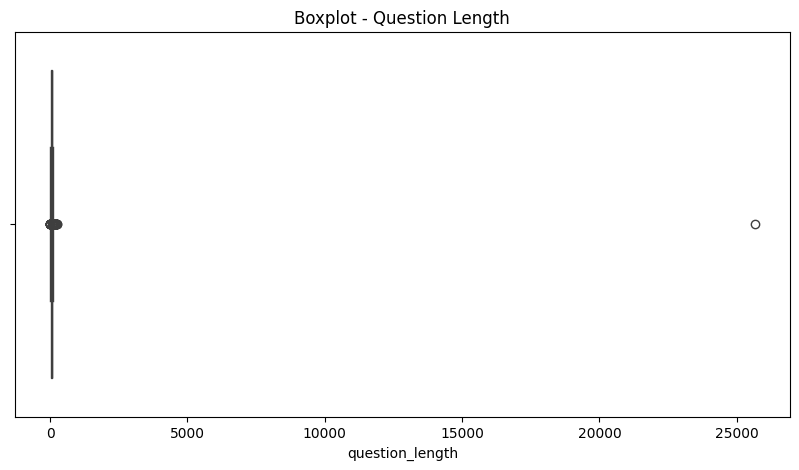

In [65]:
plt.figure(figsize=(10,5))
sns.boxplot(x=train_df["question_length"])
plt.title("Boxplot - Question Length")
plt.show()

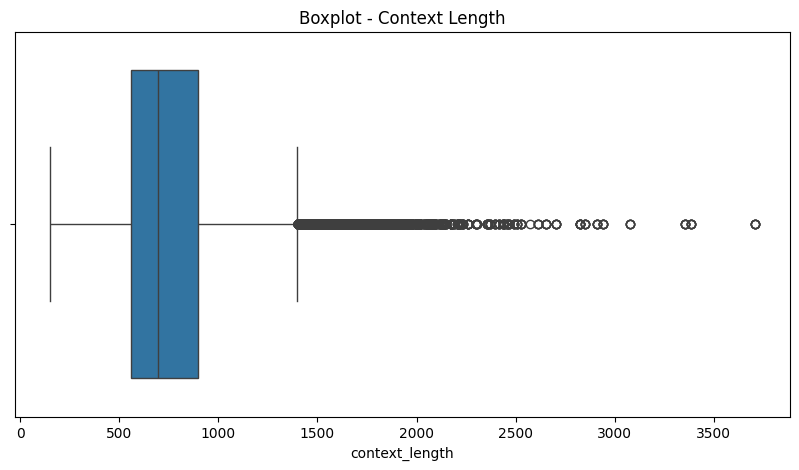

In [67]:
plt.figure(figsize=(10,5))
sns.boxplot(x=train_df["context_length"])
plt.title("Boxplot - Context Length")
plt.show()

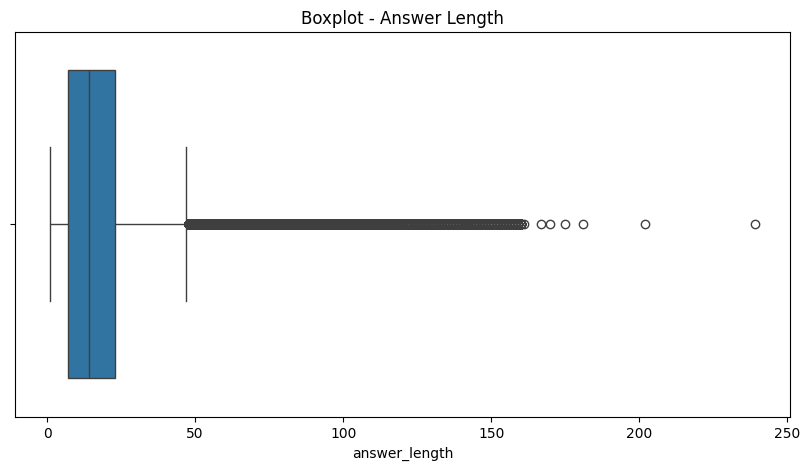

In [69]:
plt.figure(figsize=(10,5))
sns.boxplot(x=train_df["answer_length"])
plt.title("Boxplot - Answer Length")
plt.show()

In [73]:
train_df["answer_text"] = train_df["answers"].apply(lambda x: x["text"][0] if len(x["text"]) > 0 else "")
val_df["answer_text"]   = val_df["answers"].apply(lambda x: x["text"][0] if len(x["text"]) > 0 else "")

In [75]:
train_df["question_len"] = train_df["question"].apply(len)
train_df["context_len"] = train_df["context"].apply(len)
train_df["answer_len"] = train_df["answer_text"].apply(len)


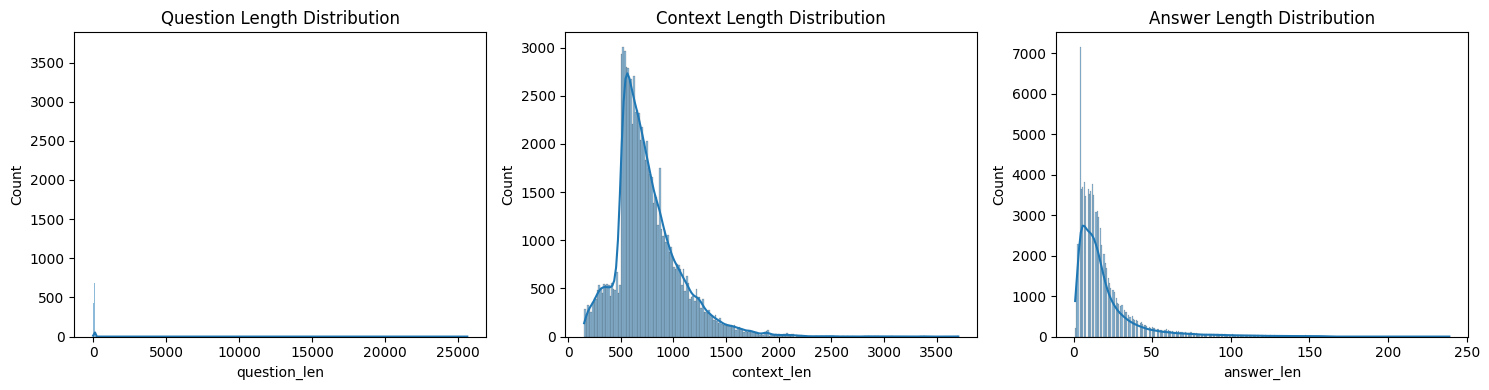

In [77]:
plt.figure(figsize=(15,4))
plt.subplot(1,3,1)
sns.histplot(train_df["question_len"], kde=True)
plt.title("Question Length Distribution")

plt.subplot(1,3,2)
sns.histplot(train_df["context_len"], kde=True)
plt.title("Context Length Distribution")

plt.subplot(1,3,3)
sns.histplot(train_df["answer_len"], kde=True)
plt.title("Answer Length Distribution")

plt.tight_layout()
plt.show()


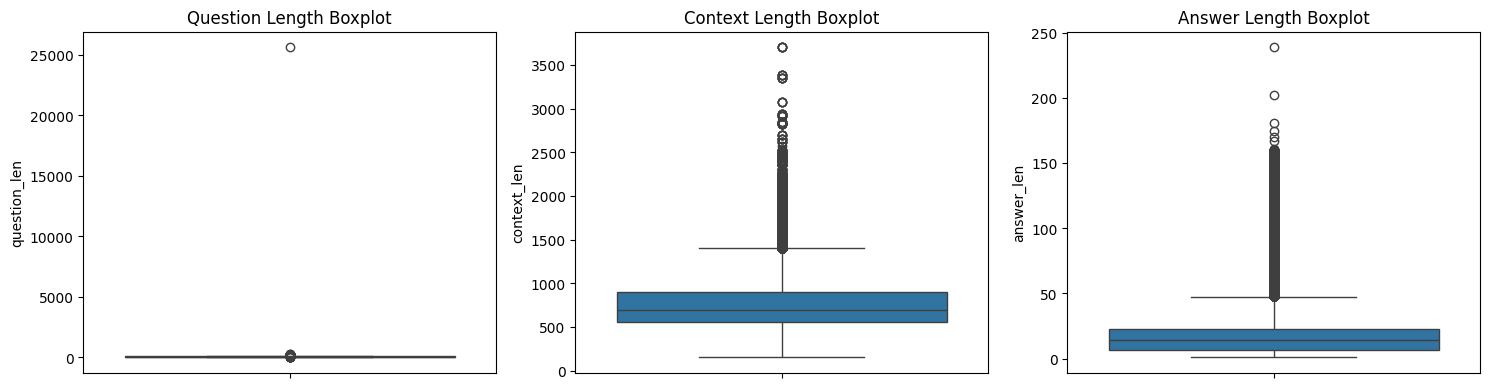

In [79]:
plt.figure(figsize=(15,4))
plt.subplot(1,3,1)
sns.boxplot(train_df["question_len"])
plt.title("Question Length Boxplot")

plt.subplot(1,3,2)
sns.boxplot(train_df["context_len"])
plt.title("Context Length Boxplot")

plt.subplot(1,3,3)
sns.boxplot(train_df["answer_len"])
plt.title("Answer Length Boxplot")

plt.tight_layout()
plt.show()

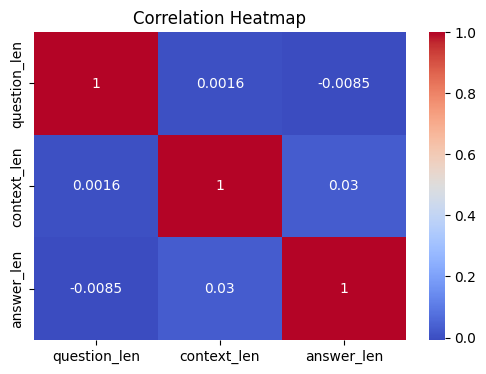

In [81]:
plt.figure(figsize=(6,4))
corr = train_df[["question_len", "context_len", "answer_len"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

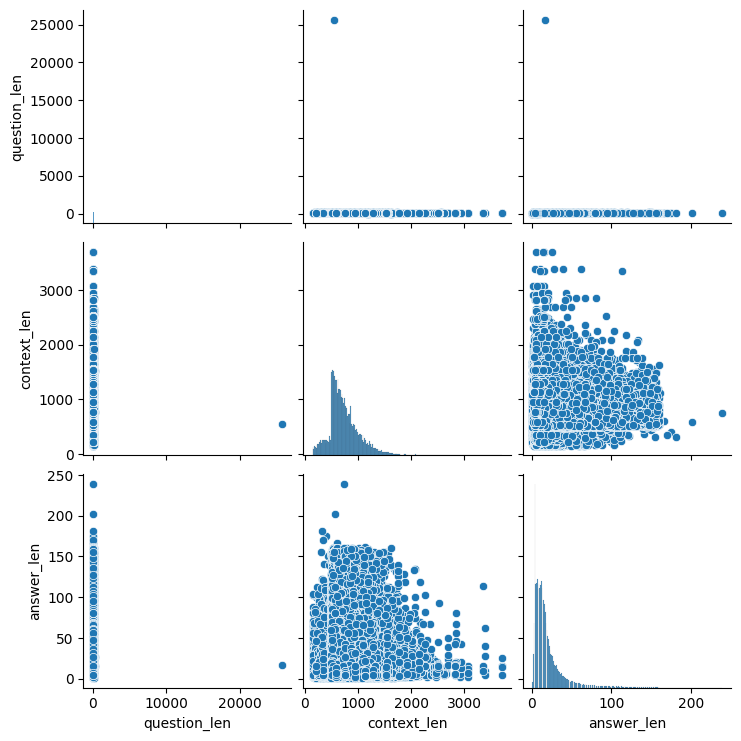

In [83]:
sns.pairplot(train_df[["question_len", "context_len", "answer_len"]])
plt.show()

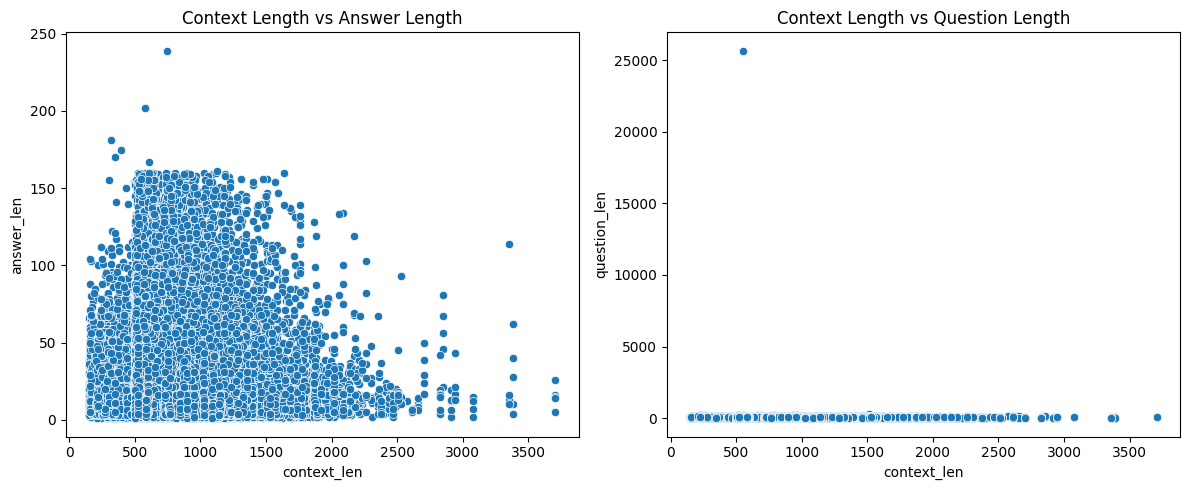

In [87]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.scatterplot(x=train_df["context_len"], y=train_df["answer_len"])
plt.title("Context Length vs Answer Length")

plt.subplot(1,2,2)
sns.scatterplot(x=train_df["context_len"], y=train_df["question_len"])
plt.title("Context Length vs Question Length")

plt.tight_layout()
plt.show()